In [1]:
print(1+1)

2


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib import animation, rc
from IPython.display import HTML
import csv
import math
import copy
import datetime
import time
from ipywidgets import Button, Output, VBox, HBox, Layout
from IPython.display import display
import ipywidgets as widgets
import matplotlib.animation as animation
from matplotlib.widgets import Button
from matplotlib.animation import FFMpegWriter

In [3]:
!pip install numpy matplotlib ipywidgets
!pip install ipympl
!pip install pillow

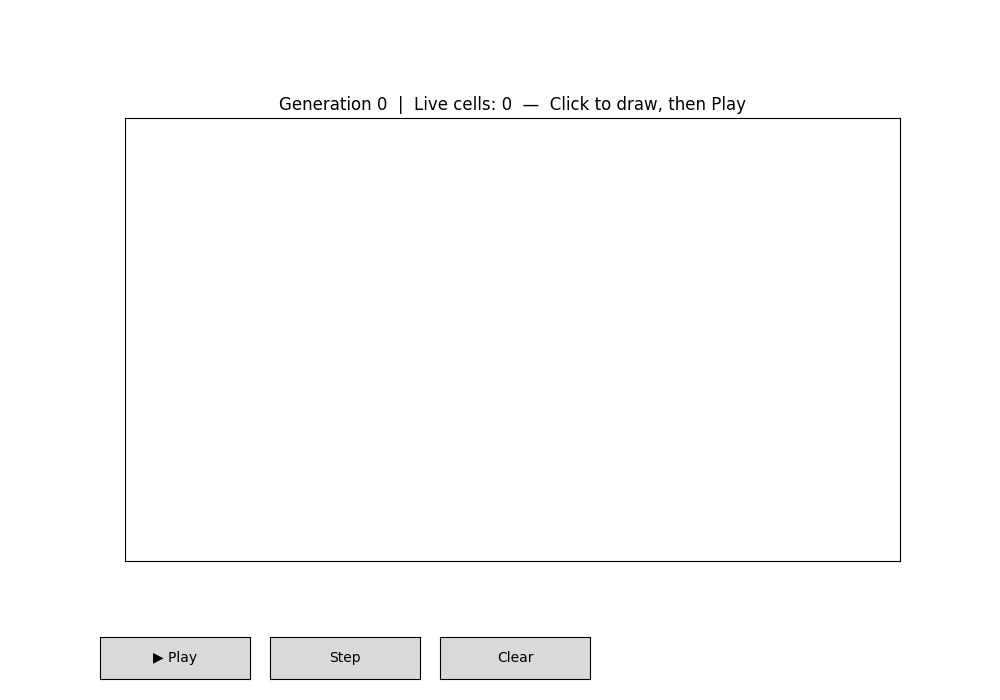

In [5]:
%matplotlib widget
ROWS, COLS = 40, 70
def next_generation(grid):
    neighbors = sum(
        np.roll(np.roll(grid, dr, axis=0), dc, axis=1)
        for dr in [-1, 0, 1] for dc in [-1, 0, 1]
        if (dr, dc) != (0, 0)
    )
    return ((neighbors == 3) | (grid & (neighbors == 2))).astype(int)
grid = np.zeros((ROWS, COLS), dtype=int)
running = False
generation = 0
fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.15)
img = ax.imshow(grid, cmap='binary', interpolation='nearest', vmin=0, vmax=1)
ax.set_xticks([])
ax.set_yticks([])
title = ax.set_title('Generation 0  |  Live cells: 0  —  Click to draw, then Play')
ax_play   = plt.axes([0.10, 0.03, 0.15, 0.06])
ax_step   = plt.axes([0.27, 0.03, 0.15, 0.06])
ax_clear  = plt.axes([0.44, 0.03, 0.15, 0.06])
btn_play   = Button(ax_play,   '▶ Play')
btn_step   = Button(ax_step,   'Step')
btn_clear  = Button(ax_clear,  'Clear')
def update_display():
    img.set_data(grid)
    title.set_text(f'Generation {generation}  |  Live cells: {grid.sum()}')
    fig.canvas.draw_idle()
def on_click(event):
    global grid
    if event.inaxes == ax and not running:
        c = int(round(event.xdata))
        r = int(round(event.ydata))
        if 0 <= r < ROWS and 0 <= c < COLS:
            grid[r, c] = 1 - grid[r, c]
            update_display()
fig.canvas.mpl_connect('button_press_event', on_click)
def animate(frame):
    global grid, generation
    if running:
        grid = next_generation(grid)
        generation += 1
        update_display()
ani = animation.FuncAnimation(fig, animate, interval=150, cache_frame_data=False)
def on_play(event):
    global running
    running = not running
    btn_play.label.set_text('⏸ Pause' if running else '▶ Play')
    fig.canvas.draw_idle()
def on_step(event):
    global grid, generation
    if not running:
        grid = next_generation(grid)
        generation += 1
        update_display()
def on_clear(event):
    global grid, generation, running
    running = False
    btn_play.label.set_text('▶ Play')
    grid = np.zeros((ROWS, COLS), dtype=int)
    generation = 0
    update_display()
btn_play.on_clicked(on_play)
btn_step.on_clicked(on_step)
btn_clear.on_clicked(on_clear)
plt.show()

In [ ]:
%matplotlib widget


ROWS, COLS = 30, 40

def next_generation(grid):
    neighbors = sum(
        np.roll(np.roll(grid, dr, axis=0), dc, axis=1)
        for dr in [-1, 0, 1] for dc in [-1, 0, 1]
        if (dr, dc) != (0, 0)
    )
    return ((neighbors == 3) | (grid & (neighbors == 2))).astype(int)

grid = np.zeros((ROWS, COLS), dtype=int)
running = False
generation = 0

fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.15)
img = ax.imshow(grid, cmap='binary', interpolation='nearest', vmin=0, vmax=1)
ax.set_xticks([])
ax.set_yticks([])
title = ax.set_title('Generation 0  |  Live cells: 0  —  Oscillators')

ax_play   = plt.axes([0.10, 0.03, 0.15, 0.06])
ax_step   = plt.axes([0.27, 0.03, 0.15, 0.06])
ax_clear  = plt.axes([0.44, 0.03, 0.15, 0.06])

btn_play   = Button(ax_play,   '▶ Play')
btn_step   = Button(ax_step,   'Step')
btn_clear  = Button(ax_clear,  'Clear')

def update_display():
    img.set_data(grid)
    title.set_text(f'Generation {generation}  |  Live cells: {grid.sum()}')
    fig.canvas.draw_idle()

def on_click(event):
    global grid
    if event.inaxes == ax and not running:
        c = int(round(event.xdata))
        r = int(round(event.ydata))
        if 0 <= r < ROWS and 0 <= c < COLS:
            grid[r, c] = 1 - grid[r, c]
            update_display()

fig.canvas.mpl_connect('button_press_event', on_click)

def animate(frame):
    global grid, generation
    if running:
        grid = next_generation(grid)
        generation += 1
        update_display()

ani = animation.FuncAnimation(fig, animate, interval=150, cache_frame_data=False)

def on_play(event):
    global running
    running = not running
    btn_play.label.set_text('⏸ Pause' if running else '▶ Play')
    fig.canvas.draw_idle()

def on_step(event):
    global grid, generation
    if not running:
        grid = next_generation(grid)
        generation += 1
        update_display()

def on_clear(event):
    global grid, generation, running
    running = False
    btn_play.label.set_text('▶ Play')
    grid = np.zeros((ROWS, COLS), dtype=int)
    generation = 0
    update_display()



btn_play.on_clicked(on_play)
btn_step.on_clicked(on_step)
btn_clear.on_clicked(on_clear)

plt.show()


grid = np.zeros((ROWS, COLS), dtype=int)
live_cells = [(5, 10), (5, 11), (5, 12), (11, 10), (10, 11), (11, 11),(12, 10),(12, 11),(13,10), (18,10),(18,11),(19,10),(19,11),(20,12),(20,13),(21,12),(21,13),
             (5, 28), (6, 28), (8,28), (9,27),(9,29), (11,27),(11,28),(11,29), (14,27),(14,28),(14,29), (16,27),(17,28),(16,29), (19,28),(20,28)]
for r, c in live_cells:
    grid[r, c] = 1

In [ ]:
%matplotlib widget


ROWS, COLS = 25, 30

def next_generation(grid):
    neighbors = sum(
        np.roll(np.roll(grid, dr, axis=0), dc, axis=1)
        for dr in [-1, 0, 1] for dc in [-1, 0, 1]
        if (dr, dc) != (0, 0)
    )
    return ((neighbors == 3) | (grid & (neighbors == 2))).astype(int)

grid = np.zeros((ROWS, COLS), dtype=int)
running = False
generation = 0

fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.15)
img = ax.imshow(grid, cmap='binary', interpolation='nearest', vmin=0, vmax=1)
ax.set_xticks([])
ax.set_yticks([])
title = ax.set_title('Generation 0  |  Live cells: 0  —  Still lifes')

ax_play   = plt.axes([0.10, 0.03, 0.15, 0.06])
ax_step   = plt.axes([0.27, 0.03, 0.15, 0.06])
ax_clear  = plt.axes([0.44, 0.03, 0.15, 0.06])

btn_play   = Button(ax_play,   '▶ Play')
btn_step   = Button(ax_step,   'Step')
btn_clear  = Button(ax_clear,  'Clear')

def update_display():
    img.set_data(grid)
    title.set_text(f'Generation {generation}  |  Live cells: {grid.sum()}')
    fig.canvas.draw_idle()

def on_click(event):
    global grid
    if event.inaxes == ax and not running:
        c = int(round(event.xdata))
        r = int(round(event.ydata))
        if 0 <= r < ROWS and 0 <= c < COLS:
            grid[r, c] = 1 - grid[r, c]
            update_display()

fig.canvas.mpl_connect('button_press_event', on_click)

def animate(frame):
    global grid, generation
    if running:
        grid = next_generation(grid)
        generation += 1
        update_display()

ani = animation.FuncAnimation(fig, animate, interval=150, cache_frame_data=False)

def on_play(event):
    global running
    running = not running
    btn_play.label.set_text('⏸ Pause' if running else '▶ Play')
    fig.canvas.draw_idle()

def on_step(event):
    global grid, generation
    if not running:
        grid = next_generation(grid)
        generation += 1
        update_display()

def on_clear(event):
    global grid, generation, running
    running = False
    btn_play.label.set_text('▶ Play')
    grid = np.zeros((ROWS, COLS), dtype=int)
    generation = 0
    update_display()



btn_play.on_clicked(on_play)
btn_step.on_clicked(on_step)
btn_clear.on_clicked(on_clear)

plt.show()


grid = np.zeros((ROWS, COLS), dtype=int)
live_cells = [(5, 5), (5, 6), (6, 5), (6, 6),
             (9, 6), (10, 5), (9, 7), (10,8), (11,6), (11,7),
             (16, 5), (15, 6), (15, 7), (16,8), (17,8), (17,6), (18,7),
             (5,15),(5,16),(6,15),(6,17),(7,16),
             (12,16),(12,17), (13,15), (14,15), (15,16), (15,17), (13,18), (14,18)]

for r, c in live_cells:
    grid[r, c] = 1

In [ ]:
%matplotlib widget


ROWS, COLS = 50, 50

def next_generation(grid):
    neighbors = sum(
        np.roll(np.roll(grid, dr, axis=0), dc, axis=1)
        for dr in [-1, 0, 1] for dc in [-1, 0, 1]
        if (dr, dc) != (0, 0)
    )
    return ((neighbors == 3) | (grid & (neighbors == 2))).astype(int)

grid = np.zeros((ROWS, COLS), dtype=int)
running = False
generation = 0

fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.15)
img = ax.imshow(grid, cmap='binary', interpolation='nearest', vmin=0, vmax=1)
ax.set_xticks([])
ax.set_yticks([])
title = ax.set_title('Generation 0  |  Live cells: 0  —  Spaceships')

ax_play   = plt.axes([0.10, 0.03, 0.15, 0.06])
ax_step   = plt.axes([0.27, 0.03, 0.15, 0.06])
ax_clear  = plt.axes([0.44, 0.03, 0.15, 0.06])

btn_play   = Button(ax_play,   '▶ Play')
btn_step   = Button(ax_step,   'Step')
btn_clear  = Button(ax_clear,  'Clear')

def update_display():
    img.set_data(grid)
    title.set_text(f'Generation {generation}  |  Live cells: {grid.sum()}')
    fig.canvas.draw_idle()

def on_click(event):
    global grid
    if event.inaxes == ax and not running:
        c = int(round(event.xdata))
        r = int(round(event.ydata))
        if 0 <= r < ROWS and 0 <= c < COLS:
            grid[r, c] = 1 - grid[r, c]
            update_display()

fig.canvas.mpl_connect('button_press_event', on_click)

def animate(frame):
    global grid, generation
    if running:
        grid = next_generation(grid)
        generation += 1
        update_display()

ani = animation.FuncAnimation(fig, animate, interval=150, cache_frame_data=False)

def on_play(event):
    global running
    running = not running
    btn_play.label.set_text('⏸ Pause' if running else '▶ Play')
    fig.canvas.draw_idle()

def on_step(event):
    global grid, generation
    if not running:
        grid = next_generation(grid)
        generation += 1
        update_display()

def on_clear(event):
    global grid, generation, running
    running = False
    btn_play.label.set_text('▶ Play')
    grid = np.zeros((ROWS, COLS), dtype=int)
    generation = 0
    update_display()



btn_play.on_clicked(on_play)
btn_step.on_clicked(on_step)
btn_clear.on_clicked(on_clear)

plt.show()


grid = np.zeros((ROWS, COLS), dtype=int)
live_cells = [(5, 5), (5, 7), (6, 6), (6, 7),(7, 6),
              (15,6),(15,7), (16,4),(16,5),(16,7),(16,8), (17,4),(17,5),(17,6),(17,7), (18,5),(18,6)]

for r, c in live_cells:
    grid[r, c] = 1

In [ ]:
%matplotlib widget
ROWS, COLS = 60, 100
def next_generation(grid):
    neighbors = sum(
        np.roll(np.roll(grid, dr, axis=0), dc, axis=1)
        for dr in [-1, 0, 1] for dc in [-1, 0, 1]
        if (dr, dc) != (0, 0)
    )
    return ((neighbors == 3) | (grid & (neighbors == 2))).astype(int)
grid = np.zeros((ROWS, COLS), dtype=int)
running = False
generation = 0
fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.15)
img = ax.imshow(grid, cmap='binary', interpolation='nearest', vmin=0, vmax=1)
ax.set_xticks([])
ax.set_yticks([])
title = ax.set_title('Generation 0  |  Live cells: 0  —  Click to draw, then Play')
ax_play   = plt.axes([0.10, 0.03, 0.15, 0.06])
ax_step   = plt.axes([0.27, 0.03, 0.15, 0.06])
ax_clear  = plt.axes([0.44, 0.03, 0.15, 0.06])
btn_play   = Button(ax_play,   '▶ Play')
btn_step   = Button(ax_step,   'Step')
btn_clear  = Button(ax_clear,  'Clear')
def update_display():
    img.set_data(grid)
    title.set_text(f'Generation {generation}  |  Live cells: {grid.sum()}')
    fig.canvas.draw_idle()
def on_click(event):
    global grid
    if event.inaxes == ax and not running:
        c = int(round(event.xdata))
        r = int(round(event.ydata))
        if 0 <= r < ROWS and 0 <= c < COLS:
            grid[r, c] = 1 - grid[r, c]
            update_display()
fig.canvas.mpl_connect('button_press_event', on_click)
def animate(frame):
    global grid, generation
    if running:
        grid = next_generation(grid)
        generation += 1
        update_display()
ani = animation.FuncAnimation(fig, animate, interval=150, cache_frame_data=False)

def on_play(event):
    global running
    running = not running
    btn_play.label.set_text('⏸ Pause' if running else '▶ Play')
    fig.canvas.draw_idle()
def on_step(event):
    global grid, generation
    if not running:
        grid = next_generation(grid)
        generation += 1
        update_display()
def on_clear(event):
    global grid, generation, running
    running = False
    btn_play.label.set_text('▶ Play')
    grid = np.zeros((ROWS, COLS), dtype=int)
    generation = 0
    update_display()
btn_play.on_clicked(on_play)
btn_step.on_clicked(on_step)
btn_clear.on_clicked(on_clear)
plt.show()



grid = np.zeros((ROWS, COLS), dtype=int)

# Gosper Glider Gun
gun_cells = [
    (5, 1), (5, 2), (6, 1), (6, 2),                          # Left square
    (5, 11), (6, 11), (7, 11),                                # Left middle
    (4, 12), (8, 12),
    (3, 13), (9, 13),
    (3, 14), (9, 14),
    (6, 15),
    (4, 16), (8, 16),
    (5, 17), (6, 17), (7, 17),
    (6, 18),                                                   # Left gun body
    (3, 21), (4, 21), (5, 21),                                # Right middle
    (3, 22), (4, 22), (5, 22),
    (2, 23), (6, 23),
    (1, 25), (2, 25), (6, 25), (7, 25),                      # Right flank
    (3, 35), (4, 35),                                         # Right square
    (3, 36), (4, 36),
]

for r, c in gun_cells:
    grid[r, c] = 1

Saved game_of_life.mp4


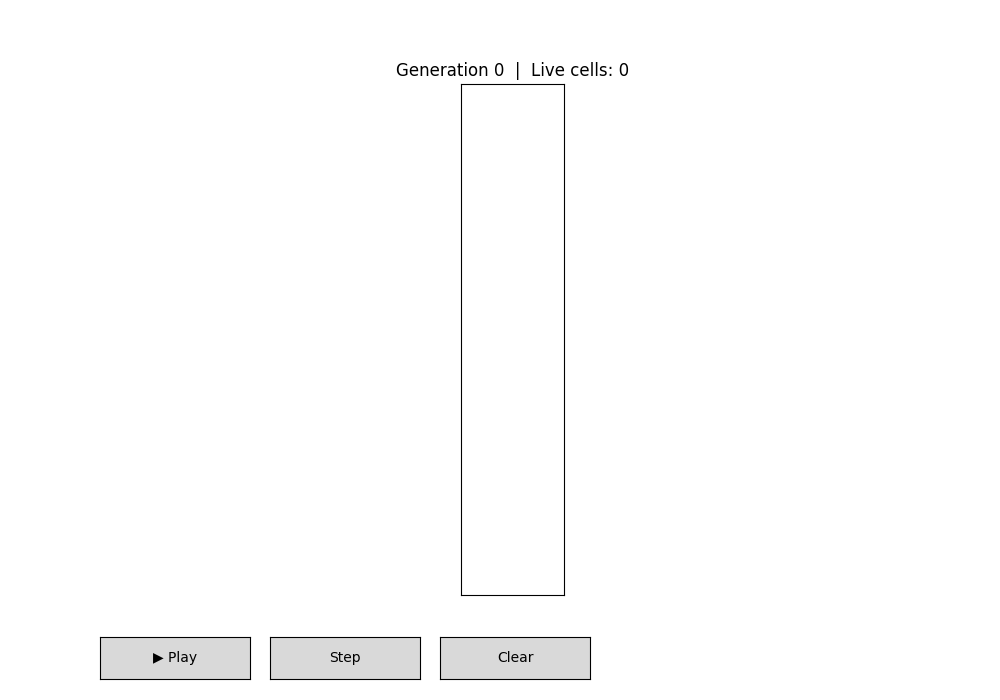

In [7]:
%matplotlib widget


ROWS, COLS = 200, 40



def next_generation(grid):
    neighbors = sum(
        np.roll(np.roll(grid, dr, axis=0), dc, axis=1)
        for dr in [-1, 0, 1] for dc in [-1, 0, 1]
        if (dr, dc) != (0, 0)
    )
    return ((neighbors == 3) | (grid & (neighbors == 2))).astype(int)

# Initialize grid BEFORE using it
grid = np.zeros((ROWS, COLS), dtype=int)

# Stabilized switch engine (block-laying type) — Charles Corderman, 1971
pattern = [
    ".OOO......O.....O......OOO.",
    "O..O.....OOO...OOO.....O..O",
    "...O....OO.O...O.OO....O...",
    "...O...................O....",
    "...O..O.............O..O...",
    "...O..OO...........OO..O...",
    "..O...OO...........OO...O..",
]

offset_r, offset_c = 5, 5
for r, row in enumerate(pattern):
    for c, ch in enumerate(row):
        if ch == 'O':
            grid[offset_r + r][offset_c + c] = 1

gun_cells = []




running = False
generation = 0

fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.15)
img = ax.imshow(grid, cmap='binary', interpolation='nearest', vmin=0, vmax=1)
ax.set_xticks([])
ax.set_yticks([])
title = ax.set_title('Generation 0  |  Live cells: 0  —  Click to draw, then Play')

ax_play  = plt.axes([0.10, 0.03, 0.15, 0.06])
ax_step  = plt.axes([0.27, 0.03, 0.15, 0.06])
ax_clear = plt.axes([0.44, 0.03, 0.15, 0.06])
btn_play  = Button(ax_play,  '▶ Play')
btn_step  = Button(ax_step,  'Step')
btn_clear = Button(ax_clear, 'Clear')

def update_display():
    img.set_data(grid)
    title.set_text(f'Generation {generation}  |  Live cells: {grid.sum()}')
    fig.canvas.draw_idle()

def on_click(event):
    global grid
    if event.inaxes == ax and not running:
        c = int(round(event.xdata))
        r = int(round(event.ydata))
        if 0 <= r < ROWS and 0 <= c < COLS:
            grid[r, c] = 1 - grid[r, c]
            update_display()

fig.canvas.mpl_connect('button_press_event', on_click)

def animate(frame):
    global grid, generation
    grid = next_generation(grid)
    generation += 1
    update_display()

def on_play(event):
    global running
    running = not running
    btn_play.label.set_text('⏸ Pause' if running else '▶ Play')
    fig.canvas.draw_idle()

def on_step(event):
    global grid, generation
    if not running:
        grid = next_generation(grid)
        generation += 1
        update_display()

def on_clear(event):
    global grid, generation, running
    running = False
    btn_play.label.set_text('▶ Play')
    grid = np.zeros((ROWS, COLS), dtype=int)
    generation = 0
    update_display()

btn_play.on_clicked(on_play)
btn_step.on_clicked(on_step)
btn_clear.on_clicked(on_clear)

# --- Save 100 generations as MP4 ---
ani_save = animation.FuncAnimation(fig, animate, frames=360, interval=150, cache_frame_data=False)
ani_save.save('game_of_life.mp4', writer=FFMpegWriter(fps=10))
print("Saved game_of_life.mp4")

# Reset grid so interactive session starts fresh from gen 0
grid = np.zeros((ROWS, COLS), dtype=int)
for r, c in gun_cells:
    grid[r, c] = 1
generation = 0
update_display()

# --- Interactive animation ---
ani = animation.FuncAnimation(fig, animate, interval=200, cache_frame_data=False)
plt.show()



Saving MP4...
Saved game_of_life.mp4


/opt/venv/lib/python3.12/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


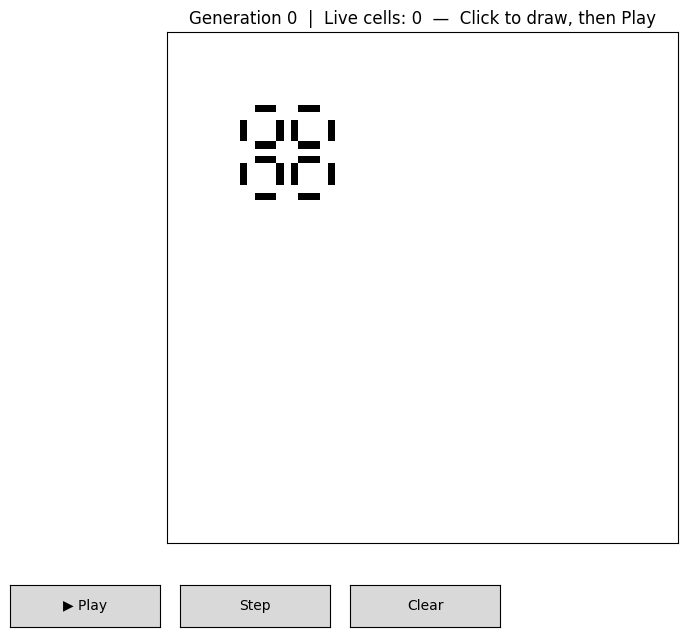

In [18]:

ROWS, COLS = 70, 70

def next_generation(grid):
    neighbors = sum(
        np.roll(np.roll(grid, dr, axis=0), dc, axis=1)
        for dr in [-1, 0, 1] for dc in [-1, 0, 1]
        if (dr, dc) != (0, 0)
    )
    return ((neighbors == 3) | (grid & (neighbors == 2))).astype(int)

def parse_rle(rle_string, offset_r=10, offset_c=10):
    lines = [l for l in rle_string.strip().split('\n') if not l.startswith('#')]
    lines = [l for l in lines if not l.strip().startswith('x')]
    rle = ''.join(lines).split('!')[0]
    cells = []
    r, c = 0, 0
    count_str = ''
    for ch in rle:
        if ch.isdigit():
            count_str += ch
        else:
            count = int(count_str) if count_str else 1
            count_str = ''
            if ch == 'b':
                c += count
            elif ch == 'o':
                for i in range(count):
                    cells.append((offset_r + r, offset_c + c + i))
                c += count
            elif ch == '$':
                r += count
                c = 0
    return cells

rle = """
x = 13, y = 13, rule = B3/S23
2b3o3b3o2b$12b$o4bobo4bo$o4bobo4bo$o4bobo4bo$2b3o3b3o2b$12b$2b3o3b3o2b$
o4bobo4bo$o4bobo4bo$o4bobo4bo$12b$2b3o3b3o!
"""

# Initialize grid
gun_cells = parse_rle(rle, offset_r=10, offset_c=10)

def make_grid():
    g = np.zeros((ROWS, COLS), dtype=int)
    for r, c in gun_cells:
        if 0 <= r < ROWS and 0 <= c < COLS:
            g[r, c] = 1
    return g

grid = make_grid()

# --- SAVE MP4 FIRST (before any interactive setup) ---
print("Saving MP4...")
save_grid = make_grid()

def animate_save(frame):
    global save_grid
    save_grid = next_generation(save_grid)
    img_save.set_data(save_grid)
    return [img_save]

fig_save, ax_save = plt.subplots(figsize=(10, 10))
ax_save.set_xticks([])
ax_save.set_yticks([])
img_save = ax_save.imshow(save_grid, cmap='binary', interpolation='nearest', vmin=0, vmax=1)
ani_save = animation.FuncAnimation(fig_save, animate_save, frames=300, interval=100, cache_frame_data=False)
ani_save.save('game_of_life.mp4', writer=FFMpegWriter(fps=10))
plt.close(fig_save)
print("Saved game_of_life.mp4")

# --- INTERACTIVE WINDOW ---
running = False
generation = 0
fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.15)
img = ax.imshow(grid, cmap='binary', interpolation='nearest', vmin=0, vmax=1)
ax.set_xticks([])
ax.set_yticks([])
title = ax.set_title('Generation 0  |  Live cells: 0  —  Click to draw, then Play')
ax_play   = plt.axes([0.10, 0.03, 0.15, 0.06])
ax_step   = plt.axes([0.27, 0.03, 0.15, 0.06])
ax_clear  = plt.axes([0.44, 0.03, 0.15, 0.06])
btn_play   = Button(ax_play,   '▶ Play')
btn_step   = Button(ax_step,   'Step')
btn_clear  = Button(ax_clear,  'Clear')

def update_display():
    img.set_data(grid)
    title.set_text(f'Generation {generation}  |  Live cells: {grid.sum()}')
    fig.canvas.draw_idle()

def on_click(event):
    global grid
    if event.inaxes == ax and not running:
        c = int(round(event.xdata))
        r = int(round(event.ydata))
        if 0 <= r < ROWS and 0 <= c < COLS:
            grid[r, c] = 1 - grid[r, c]
            update_display()

fig.canvas.mpl_connect('button_press_event', on_click)

def animate(frame):
    global grid, generation
    if running:
        grid = next_generation(grid)
        generation += 1
        update_display()

ani = animation.FuncAnimation(fig, animate, interval=100, cache_frame_data=False)

def on_play(event):
    global running
    running = not running
    btn_play.label.set_text('⏸ Pause' if running else '▶ Play')
    fig.canvas.draw_idle()

def on_step(event):
    global grid, generation
    if not running:
        grid = next_generation(grid)
        generation += 1
        update_display()

def on_clear(event):
    global grid, generation, running
    running = False
    btn_play.label.set_text('▶ Play')
    grid = make_grid()
    generation = 0
    update_display()

btn_play.on_clicked(on_play)
btn_step.on_clicked(on_step)
btn_clear.on_clicked(on_clear)
plt.show()